In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

Best parameters: {'model__n_estimators': 300, 'model__min_samples_leaf': 4, 'model__max_depth': 30}
Best CV score: 0.9428823321941218
Test ROC AUC: 0.951376538987688

Confusion Matrix:
 [[7164  146]
 [ 521  407]]

Classification Report:
               precision    recall  f1-score   support

          no       0.93      0.98      0.96      7310
         yes       0.74      0.44      0.55       928

    accuracy                           0.92      8238
   macro avg       0.83      0.71      0.75      8238
weighted avg       0.91      0.92      0.91      8238



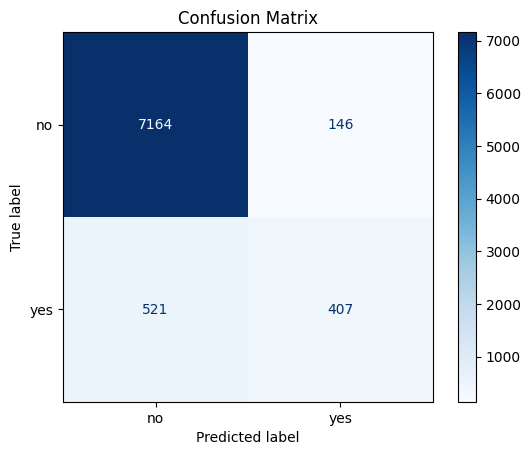

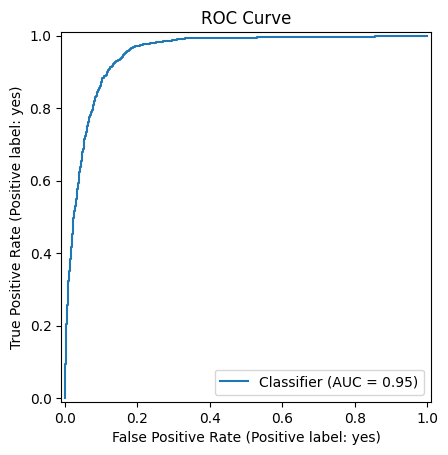

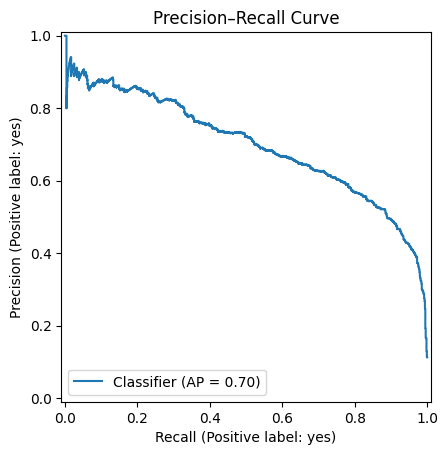

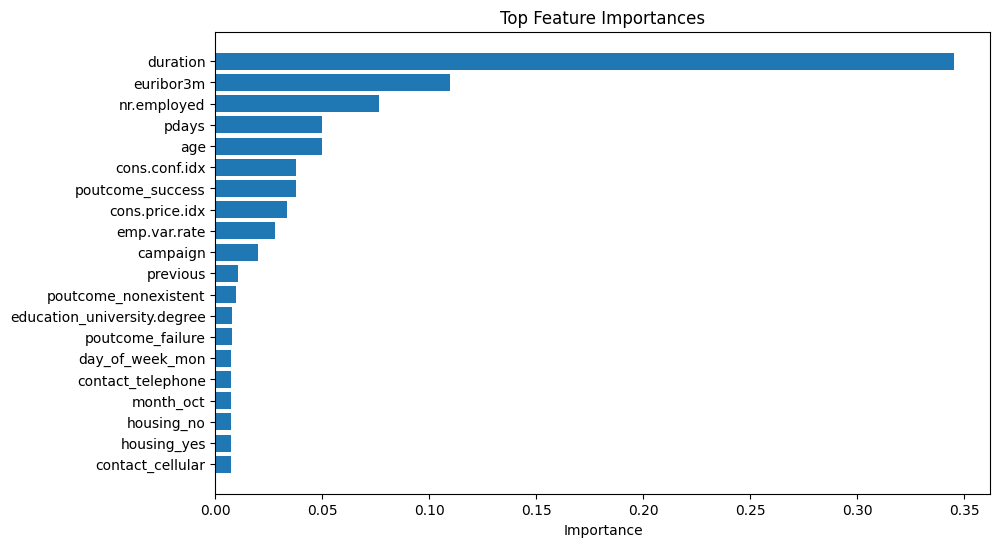

In [10]:
# -------------------------------------------------------
# Load data
# -------------------------------------------------------
data = pd.read_csv(
    r'../data/raw/bank-additional/bank-additional-full.csv',
    sep=';'
)

X = data.drop(columns=['y'])
y = data['y']

# -------------------------------------------------------
# Preprocessing + Pipeline; one-hot encode categoricals, passthrough numericals (no transformation), and use RandomForestClassifier as the model
# -------------------------------------------------------
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         make_column_selector(dtype_include=object)),
        ('num', 'passthrough',
         make_column_selector(dtype_exclude=object))
    ]
)

pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(random_state=42))
])

# -------------------------------------------------------
# Train/test split
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------------------------------
# Hyperparameter tuning; use RandomizedSearchCV for efficiency, tuning n_estimators, max_depth, and min_samples_leaf
# -------------------------------------------------------
param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_leaf': [1, 2, 4, 8]
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best CV score:", search.best_score_)

best_pipe = search.best_estimator_

# -------------------------------------------------------
# Predictions + Probabilities
# -------------------------------------------------------
y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

# -------------------------------------------------------
# Evaluation Metrics
# -------------------------------------------------------
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -------------------------------------------------------
# Confusion Matrix Plot
# -------------------------------------------------------
cm = confusion_matrix(y_test, y_pred, labels=best_pipe.named_steps['model'].classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=best_pipe.named_steps['model'].classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# -------------------------------------------------------
# ROC Curve
# -------------------------------------------------------
RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    pos_label="yes"
)
plt.title("ROC Curve")
plt.show()

# -------------------------------------------------------
# Precision–Recall Curve
# -------------------------------------------------------
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba,
    pos_label="yes"
)
plt.title("Precision–Recall Curve")
plt.show()

# -------------------------------------------------------
# Feature Importances
# -------------------------------------------------------
ohe = best_pipe.named_steps['preprocess'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out()
num_features = X.select_dtypes(exclude='object').columns
all_features = np.concatenate([cat_features, num_features])

importances = best_pipe.named_steps['model'].feature_importances_

feature_ranking = (
    pd.DataFrame({'feature': all_features, 'importance': importances})
      .sort_values('importance', ascending=False)
)

# Plot top features
top_n = 20
top_features = feature_ranking.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.show()

Run with duration feature dropped

Best parameters: {'model__n_estimators': 200, 'model__min_samples_leaf': 1, 'model__max_depth': 10}
Best CV score: 0.795915098320868
Test ROC AUC: 0.8103891987829615

Confusion Matrix:
 [[7226   84]
 [ 709  219]]

Classification Report:
               precision    recall  f1-score   support

          no       0.91      0.99      0.95      7310
         yes       0.72      0.24      0.36       928

    accuracy                           0.90      8238
   macro avg       0.82      0.61      0.65      8238
weighted avg       0.89      0.90      0.88      8238



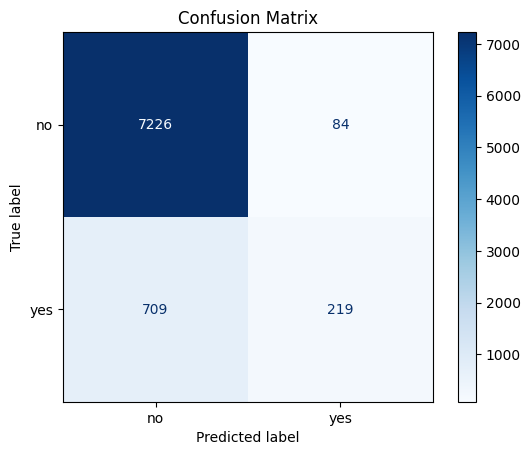

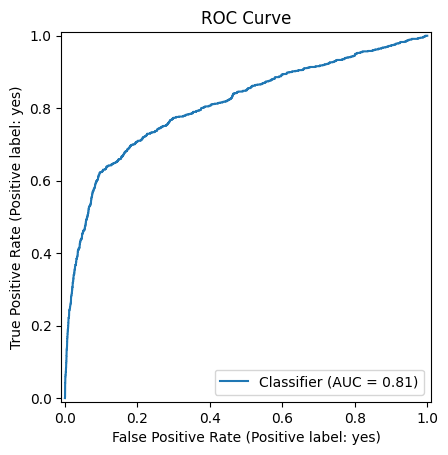

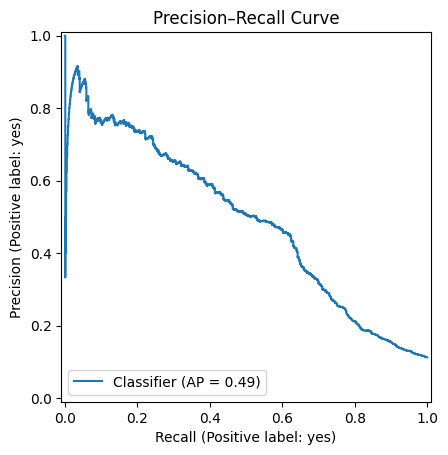

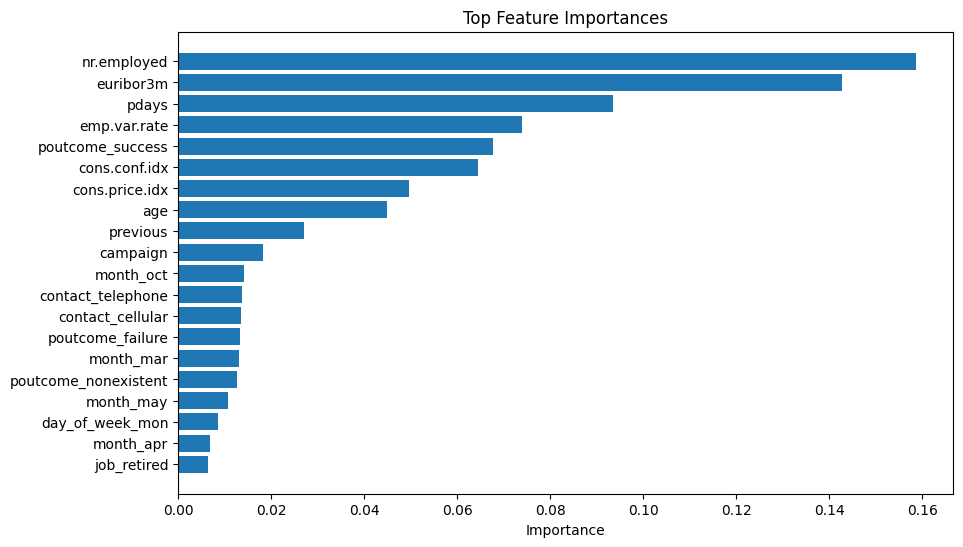

In [11]:
# Drop duration (must be removed BEFORE splitting)
if "duration" in data.columns:
    X = data.drop(columns=["duration"])

X = X.drop(columns=['y'])
y = data['y']

# -------------------------------------------------------
# Preprocessing + Pipeline
# -------------------------------------------------------
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         make_column_selector(dtype_include=object)),
        ('num', 'passthrough',
         make_column_selector(dtype_exclude=object))
    ]
)

pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(random_state=42))
])

# -------------------------------------------------------
# Train/test split
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------------------------------
# Hyperparameter tuning
# -------------------------------------------------------
param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_leaf': [1, 2, 4, 8]
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best CV score:", search.best_score_)

best_pipe = search.best_estimator_

# -------------------------------------------------------
# Predictions + Probabilities
# -------------------------------------------------------
y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

# -------------------------------------------------------
# Evaluation Metrics
# -------------------------------------------------------
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -------------------------------------------------------
# Confusion Matrix Plot
# -------------------------------------------------------
cm = confusion_matrix(y_test, y_pred, labels=best_pipe.named_steps['model'].classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=best_pipe.named_steps['model'].classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# -------------------------------------------------------
# ROC Curve
# -------------------------------------------------------
RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    pos_label="yes"
)
plt.title("ROC Curve")
plt.show()

# -------------------------------------------------------
# Precision–Recall Curve
# -------------------------------------------------------
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba,
    pos_label="yes"
)
plt.title("Precision–Recall Curve")
plt.show()

# -------------------------------------------------------
# Feature Importances
# -------------------------------------------------------
ohe = best_pipe.named_steps['preprocess'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out()
num_features = X.select_dtypes(exclude='object').columns
all_features = np.concatenate([cat_features, num_features])

importances = best_pipe.named_steps['model'].feature_importances_

feature_ranking = (
    pd.DataFrame({'feature': all_features, 'importance': importances})
      .sort_values('importance', ascending=False)
)

# Plot top features
top_n = 20
top_features = feature_ranking.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.show()

Run with imbalance handling and duration dropped

Best parameters: {'model__n_estimators': 300, 'model__min_samples_leaf': 8, 'model__max_depth': 10, 'model__class_weight': 'balanced_subsample'}
Best CV score: 0.7973477637257332
Test ROC AUC: 0.814875480565121

Confusion Matrix:
 [[6457  853]
 [ 335  593]]

Classification Report:
               precision    recall  f1-score   support

          no       0.95      0.88      0.92      7310
         yes       0.41      0.64      0.50       928

    accuracy                           0.86      8238
   macro avg       0.68      0.76      0.71      8238
weighted avg       0.89      0.86      0.87      8238



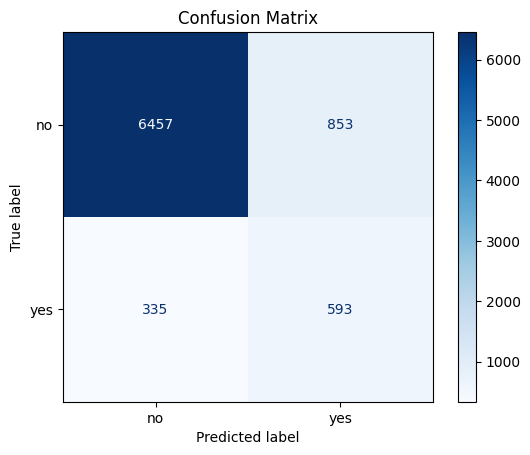

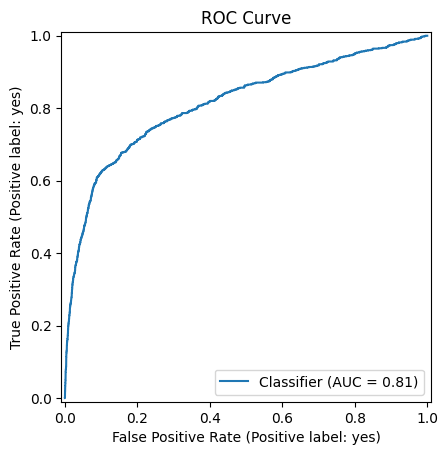

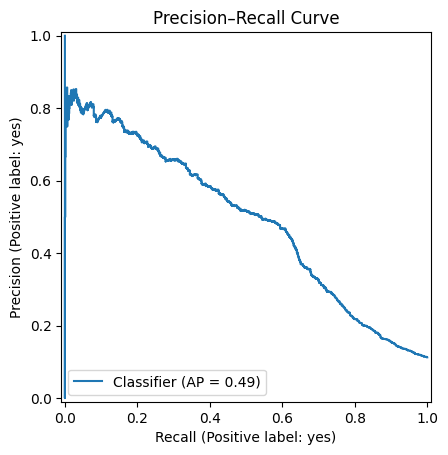

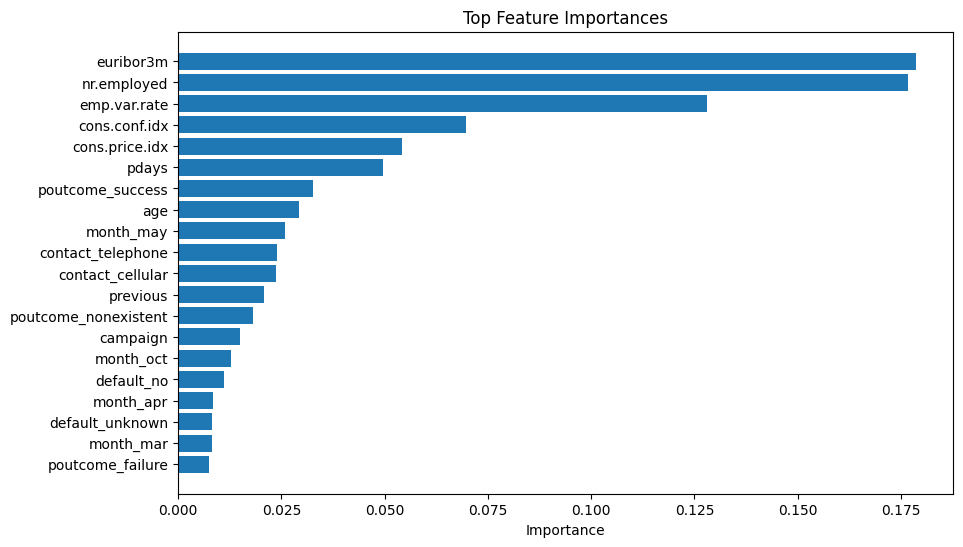

In [12]:
# Drop leakage-prone feature
if "duration" in data.columns:
    X = data.drop(columns=["duration"])

X = X.drop(columns=['y'])
y = data['y']

# -------------------------------------------------------
# Preprocessing + Pipeline
# -------------------------------------------------------
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'),
         make_column_selector(dtype_include=object)),
        ('num', 'passthrough',
         make_column_selector(dtype_exclude=object))
    ]
)

pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'   # <-- imbalance handling integrated here
    ))
])

# -------------------------------------------------------
# Train/test split
# -------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------------------------------
# Hyperparameter tuning
# -------------------------------------------------------
param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__class_weight': ['balanced', 'balanced_subsample']  # tune imbalance strategy
}

search = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print("Best CV score:", search.best_score_)

best_pipe = search.best_estimator_

# -------------------------------------------------------
# Predictions + Probabilities
# -------------------------------------------------------
y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

# -------------------------------------------------------
# Evaluation Metrics
# -------------------------------------------------------
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -------------------------------------------------------
# Confusion Matrix Plot
# -------------------------------------------------------
cm = confusion_matrix(y_test, y_pred, labels=best_pipe.named_steps['model'].classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=best_pipe.named_steps['model'].classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# -------------------------------------------------------
# ROC Curve
# -------------------------------------------------------
RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    pos_label="yes"
)
plt.title("ROC Curve")
plt.show()

# -------------------------------------------------------
# Precision–Recall Curve
# -------------------------------------------------------
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba,
    pos_label="yes"
)
plt.title("Precision–Recall Curve")
plt.show()

# -------------------------------------------------------
# Feature Importances
# -------------------------------------------------------
ohe = best_pipe.named_steps['preprocess'].named_transformers_['cat']
cat_features = ohe.get_feature_names_out()
num_features = X.select_dtypes(exclude='object').columns
all_features = np.concatenate([cat_features, num_features])

importances = best_pipe.named_steps['model'].feature_importances_

feature_ranking = (
    pd.DataFrame({'feature': all_features, 'importance': importances})
      .sort_values('importance', ascending=False)
)

# Plot top features
top_n = 20
top_features = feature_ranking.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.xlabel("Importance")
plt.show()